# Notebook for Viewing the Processed Results from process_data.py

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import trxrd

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.aspect"] = "auto"

def symmetric_clim(data, percentile=99):
    vmax = np.nanpercentile(np.abs(data), percentile)
    return -vmax, vmax

## Import h5 file path

In [ ]:
h5_path = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Sargent_Beamtime_Data\processed_data\BTO400nmS3_240Ksurv3.h5")
print(h5_path)
print(h5_path.exists())

C:\Users\lheald\Documents\Guzelturk_Lab\Sargent_Beamtime_Data\processed_data\BTO400nmS3_240Ksurv3.h5
True


### Inspect File

In [3]:
def print_h5_tree(name, obj):
    print(name)

with h5py.File(h5_path, "r") as h5:
    h5.visititems(print_h5_tree)

difference
difference/dI
difference/delta_fq
difference/delta_gr
difference/delta_sq
difference/r
difference/reference_profile
processed
processed/profiles_flat
processed/q
raw_metadata
raw_metadata/delay
raw_metadata/file_names
raw_metadata/image_number


## Load h5 Data

In [5]:
with h5py.File(h5_path, "r") as h5:
    file_names = h5["raw_metadata/file_names"][:].astype(str)
    delay = h5["raw_metadata/delay"][:]
    image_number = h5["raw_metadata/image_number"][:]

    q = h5["processed/q"][:]
    profiles_flat = h5["processed/profiles_flat"][:]

    reference_profile = h5["difference/reference_profile"][:]
    dI = h5["difference/dI"][:]
    delta_sq = h5["difference/delta_sq"][:]
    delta_fq = h5["difference/delta_fq"][:]
    r = h5["difference/r"][:]
    delta_gr = h5["difference/delta_gr"][:]

print("file_names:", file_names.shape)
print("delay:", delay.shape)
print("q:", q.shape)
print("profiles_flat:", profiles_flat.shape)
print("reference_profile:", reference_profile.shape)
print("dI:", dI.shape)
print("delta_sq:", delta_sq.shape)
print("delta_fq:", delta_fq.shape)
print("r:", r.shape)
print("delta_gr:", delta_gr.shape)

print("Number of unique delays:", len(np.unique(delay)))
print("Min delay:", np.nanmin(delay))
print("Max delay:", np.nanmax(delay))

print("Any NaNs in q?", np.isnan(q).any())
print("Any NaNs in dI?", np.isnan(dI).any())
print("Any NaNs in delta_gr?", np.isnan(delta_gr).any())

file_names: (884,)
delay: (884,)
q: (5000,)
profiles_flat: (884, 5000)
reference_profile: (5000,)
dI: (884, 5000)
delta_sq: (884, 5000)
delta_fq: (884, 5000)
r: (2000,)
delta_gr: (884, 2000)
Number of unique delays: 3
Min delay: -8e-08
Max delay: 6e-10
Any NaNs in q? False
Any NaNs in dI? True
Any NaNs in delta_gr? False


## Plot Reference Profile

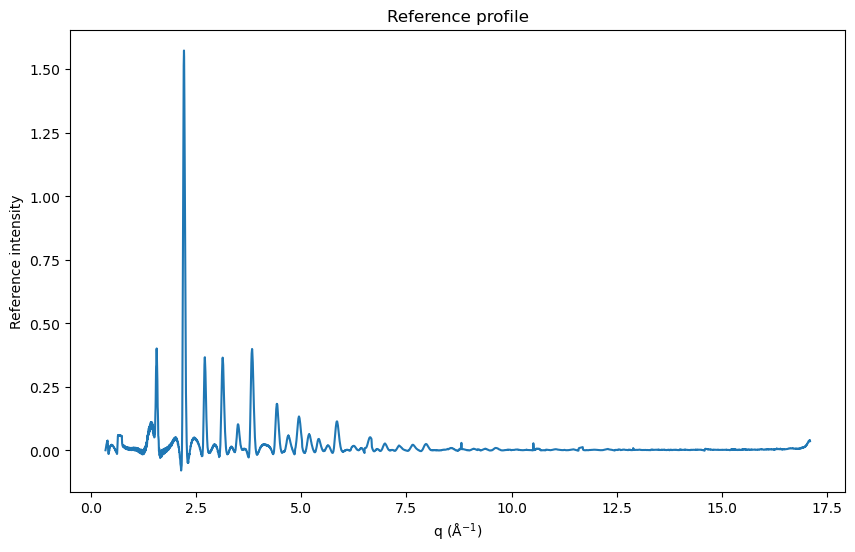

In [6]:
plt.figure()
plt.plot(q, reference_profile)
plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("Reference intensity")
plt.title("Reference profile")
plt.show()

## Average Data by Delay

In [7]:
unique_delays = np.unique(delay)

dI_avg = []
delta_sq_avg = []
delta_fq_avg = []
delta_gr_avg = []

for d in unique_delays:
    mask = delay == d
    dI_avg.append(np.nanmean(dI[mask], axis=0))
    delta_sq_avg.append(np.nanmean(delta_sq[mask], axis=0))
    delta_fq_avg.append(np.nanmean(delta_fq[mask], axis=0))
    delta_gr_avg.append(np.nanmean(delta_gr[mask], axis=0))

dI_avg = np.array(dI_avg)
delta_sq_avg = np.array(delta_sq_avg)
delta_fq_avg = np.array(delta_fq_avg)
delta_gr_avg = np.array(delta_gr_avg)

print(dI_avg.shape, delta_sq_avg.shape, delta_fq_avg.shape, delta_gr_avg.shape)

(3, 5000) (3, 5000) (3, 5000) (3, 2000)


C:\Users\lheald\AppData\Local\Temp\ipykernel_18088\2763142114.py:10: RuntimeWarning: Mean of empty slice
  dI_avg.append(np.nanmean(dI[mask], axis=0))
C:\Users\lheald\AppData\Local\Temp\ipykernel_18088\2763142114.py:11: RuntimeWarning: Mean of empty slice
  delta_sq_avg.append(np.nanmean(delta_sq[mask], axis=0))
C:\Users\lheald\AppData\Local\Temp\ipykernel_18088\2763142114.py:12: RuntimeWarning: Mean of empty slice
  delta_fq_avg.append(np.nanmean(delta_fq[mask], axis=0))


## Plot Time Resolved dI

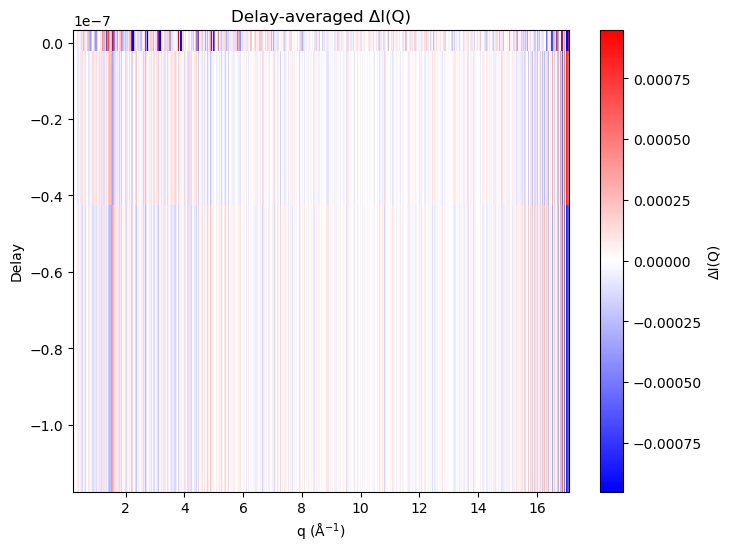

In [8]:
vmin, vmax = symmetric_clim(dI_avg, percentile=99)

plt.figure(figsize=(8, 6))
plt.pcolormesh(q, unique_delays, dI_avg, shading="auto", cmap="bwr", vmin=vmin, vmax=vmax)
plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-averaged ΔI(Q)")
plt.colorbar(label="ΔI(Q)")
plt.show()

## Plot Time Resolved dS(Q)

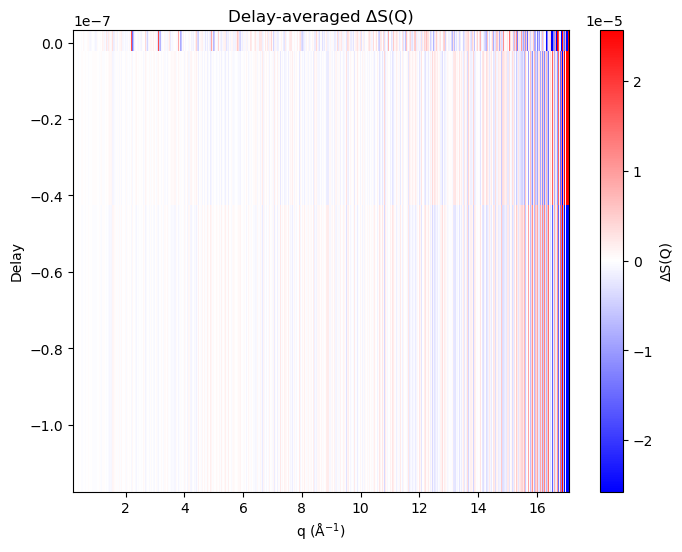

In [9]:
vmin, vmax = symmetric_clim(delta_sq_avg, percentile=99)

plt.figure(figsize=(8, 6))
plt.pcolormesh(q, unique_delays, delta_sq_avg, shading="auto", cmap="bwr", vmin=vmin, vmax=vmax)
plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-averaged ΔS(Q)")
plt.colorbar(label="ΔS(Q)")
plt.show()

## Plot Time Resolved dG(r)

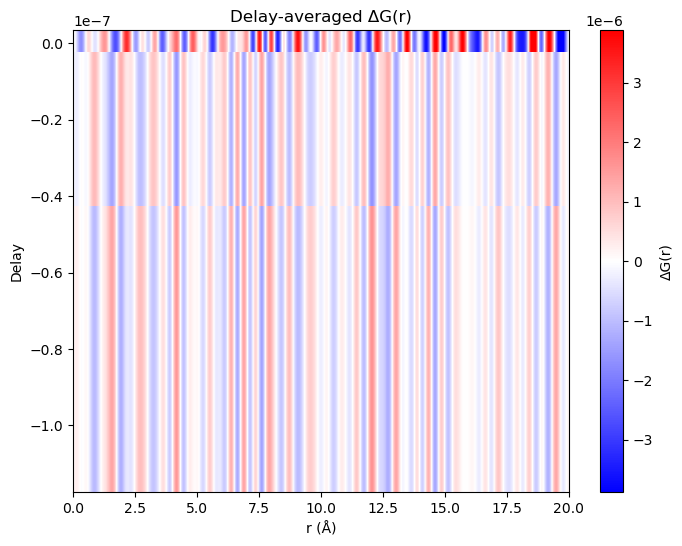

In [10]:
vmin, vmax = symmetric_clim(delta_gr_avg, percentile=99)

plt.figure(figsize=(8, 6))
plt.pcolormesh(r, unique_delays, delta_gr_avg, shading="auto", cmap="bwr", vmin=vmin, vmax=vmax)
plt.xlabel("r (Å)")
plt.ylabel("Delay")
plt.title("Delay-averaged ΔG(r)")
plt.colorbar(label="ΔG(r)")
plt.show()

## Plot Lineouts

In [ ]:
selected_delays = [-1.0, 0.0, 1.0, 5.0]  # edit these to match your data

plt.figure()
for d in selected_delays:
    idx = np.argmin(np.abs(unique_delays - d))
    plt.plot(q, dI_avg[idx], label=f"{unique_delays[idx]:.3f}")

plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("ΔI(Q)")
plt.title("Selected delay lineouts")
plt.legend()
plt.show()

In [ ]:
plt.figure()
for d in selected_delays:
    idx = np.argmin(np.abs(unique_delays - d))
    plt.plot(r, delta_gr_avg[idx], label=f"{unique_delays[idx]:.3f}")

plt.xlabel("r (Å)")
plt.ylabel("ΔG(r)")
plt.title("Selected delay lineouts")
plt.legend()
plt.show()